In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.model_selection import train_test_split

In [20]:
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y = np.array([5,7,9,11,13,15,17,19,21,23], dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

n = len(X_train)

print("X_train", X_train)
print("y_train", y_train)

X_train [ 6.  1.  8.  3. 10.  5.  4.  7.]
y_train [15.  5. 19.  9. 23. 13. 11. 17.]


In [21]:
# ==========================
# Gradient Descent
# ==========================

w = 0.0
b = 0.0

lr = 0.01
epochs = 1000

costs = []
w_history = []
b_history = []

for epoch in range(epochs):
  
    y_pred = X_train*w + b
    cost = np.mean((y_train  - y_pred) ** 2)

    costs.append(cost)
    
    # Gradients
    dw = (-2 / n) * np.sum(X_train * (y_train  - y_pred))
    db = (-2 / n) * np.sum(y_train  - y_pred)
    
    w = w - lr * dw
    b = b - lr * db
    
    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss={cost:.4f} | "
            f"w={w:.4f} | "
            f"b={b:.4f}"
        )

print("\nTraining Complete")
print(f"Final Weight (w): {w:.4f}")
print(f"Final Bias   (b): {b:.4f}")   




Epoch   0 | Loss=225.0000 | w=1.8300 | b=0.2800
Epoch  50 | Loss=0.9277 | w=2.3217 | b=0.8179
Epoch 100 | Loss=0.6349 | w=2.2661 | b=1.1948
Epoch 150 | Loss=0.4345 | w=2.2201 | b=1.5066
Epoch 200 | Loss=0.2974 | w=2.1821 | b=1.7645
Epoch 250 | Loss=0.2035 | w=2.1507 | b=1.9779
Epoch 300 | Loss=0.1393 | w=2.1246 | b=2.1544
Epoch 350 | Loss=0.0953 | w=2.1031 | b=2.3005
Epoch 400 | Loss=0.0653 | w=2.0853 | b=2.4213
Epoch 450 | Loss=0.0447 | w=2.0706 | b=2.5212
Epoch 500 | Loss=0.0306 | w=2.0584 | b=2.6039
Epoch 550 | Loss=0.0209 | w=2.0483 | b=2.6723
Epoch 600 | Loss=0.0143 | w=2.0400 | b=2.7289
Epoch 650 | Loss=0.0098 | w=2.0331 | b=2.7757
Epoch 700 | Loss=0.0067 | w=2.0273 | b=2.8145
Epoch 750 | Loss=0.0046 | w=2.0226 | b=2.8465
Epoch 800 | Loss=0.0031 | w=2.0187 | b=2.8730
Epoch 850 | Loss=0.0021 | w=2.0155 | b=2.8950
Epoch 900 | Loss=0.0015 | w=2.0128 | b=2.9131
Epoch 950 | Loss=0.0010 | w=2.0106 | b=2.9281

Training Complete
Final Weight (w): 2.0088
Final Bias   (b): 2.9403


In [22]:
# =====================================
# Evaluation Metrics
# =====================================


y_test_pred = X_test * w + b


# MAE
mae = np.mean(np.abs(y_test - y_test_pred))

# MSE
mse = np.mean((y_test - y_test_pred) ** 2)

# RMSE
rmse = np.sqrt(mse)

# R² Score
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

# =====================================
# Results
# =====================================
print("Final Parameters")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")

print("\nEvaluation Metrics")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# =====================================
# Actual vs Predicted
# =====================================
print("\nTest Predictions")

for actual, pred in zip(y_test, y_test_pred):
    print(
        f"Actual: {actual:.2f} "
        f" Predicted: {pred:.2f}"
    )


Final Parameters
w = 2.0088
b = 2.9403

Evaluation Metrics
MAE  = 0.0308
MSE  = 0.0011
RMSE = 0.0328
R²   = 1.0000

Test Predictions
Actual: 21.00  Predicted: 21.02
Actual: 7.00  Predicted: 6.96


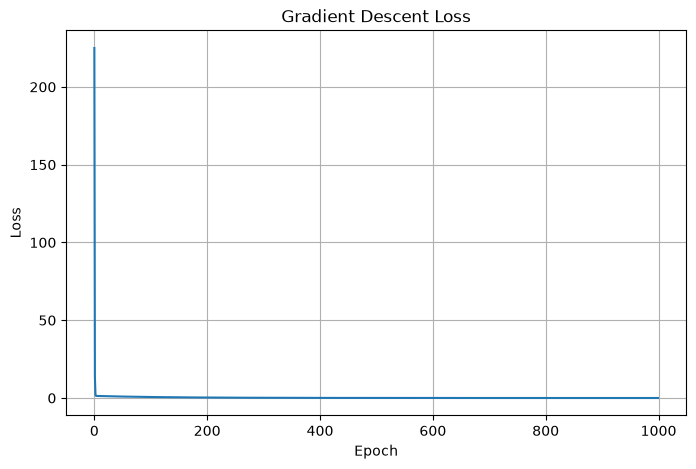

In [18]:
# =====================================
# Loss Curve
# =====================================
plt.figure(figsize=(8,5))
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss")
plt.grid(True)
plt.show()



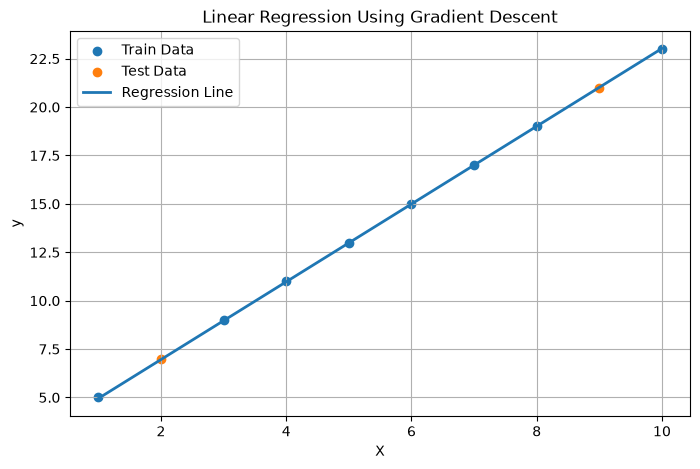

In [23]:
# =====================================
# Regression Line
# =====================================
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")

x_line = np.linspace(min(X), max(X), 100)
y_line = x_line * w + b

plt.plot(x_line, y_line, linewidth=2,
         label="Regression Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Using Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()